<a href="https://colab.research.google.com/github/utkarsha-a/AQI-Prediction-Model/blob/main/notebooks/3_train_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q

import torch
from ultralytics import YOLO

print(f"✅ Ultralytics ready")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU detected — go to Runtime > Change Runtime Type > T4 GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics ready
   PyTorch version : 2.10.0+cu128
   GPU available   : True
   GPU name        : Tesla T4
   GPU memory      : 15.6 GB


In [ ]:
import yaml, os
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/ROI_Detection/roboflow_export")
yaml_path   = str(DATASET_DIR / "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["train"] = str(DATASET_DIR / "train" / "images")
data["val"]   = str(DATASET_DIR / "valid" / "images")
data["test"]  = str(DATASET_DIR / "test"  / "images")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml paths fixed")
print(f"   train : {data['train']}")
print(f"   val   : {data['val']}")
print(f"   test  : {data['test']}")
print(f"   classes : {data['names']}")

✅ data.yaml paths fixed
   train : /content/drive/MyDrive/ROI_Detection/roboflow_export/train/images
   val   : /content/drive/MyDrive/ROI_Detection/roboflow_export/valid/images
   test  : /content/drive/MyDrive/ROI_Detection/roboflow_export/test/images
   classes : ['polyp']


In [ ]:
MODEL_SAVE_DIR = "/content/drive/MyDrive/ROI_Detection/models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

model = YOLO("yolov8m-seg.pt")  # medium segmentation model

results = model.train(
    data      = yaml_path,
    epochs    = 50,
    imgsz     = 640,
    batch     = 8,
    name      = "polyp_seg_v1",
    project   = MODEL_SAVE_DIR,
    device    = 0,
    patience  = 15,        # stops early if no improvement for 15 epochs
    save      = True,
    plots     = True,
    workers   = 2,
)

print("\n✅ Training complete")
print(f"   Best model : {MODEL_SAVE_DIR}/polyp_seg_v1/weights/best.pt")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ROI_Detection/roboflow_export/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=polyp_seg_v1, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
BEST_MODEL = f"{MODEL_SAVE_DIR}/polyp_seg_v1/weights/best.pt"

model   = YOLO(BEST_MODEL)
metrics = model.val(data=yaml_path)

print("\n" + "="*50)
print("  VALIDATION RESULTS")
print("="*50)
print(f"  mAP@0.5      : {metrics.seg.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.seg.map:.4f}")
print(f"  Precision    : {metrics.seg.mp:.4f}")
print(f"  Recall       : {metrics.seg.mr:.4f}")
print("="*50)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 9.3±3.0 MB/s, size: 25.8 KB)
val: Scanning /content/drive/MyDrive/ROI_Detection/roboflow_export/valid/labels.cache... 23 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 5.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.0s
                   all         23         22      0.827      0.727      0.753      0.526      0.881      0.773      0.775      0.513
Speed: 9.8ms preprocess, 34.5ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/segment/val

  VALIDATION RESULTS
  mAP@0.5      : 0.7747
  mAP@0.5:0.95 : 0.5131
  Precision    : 0.8814
  Recall       : 0.7727


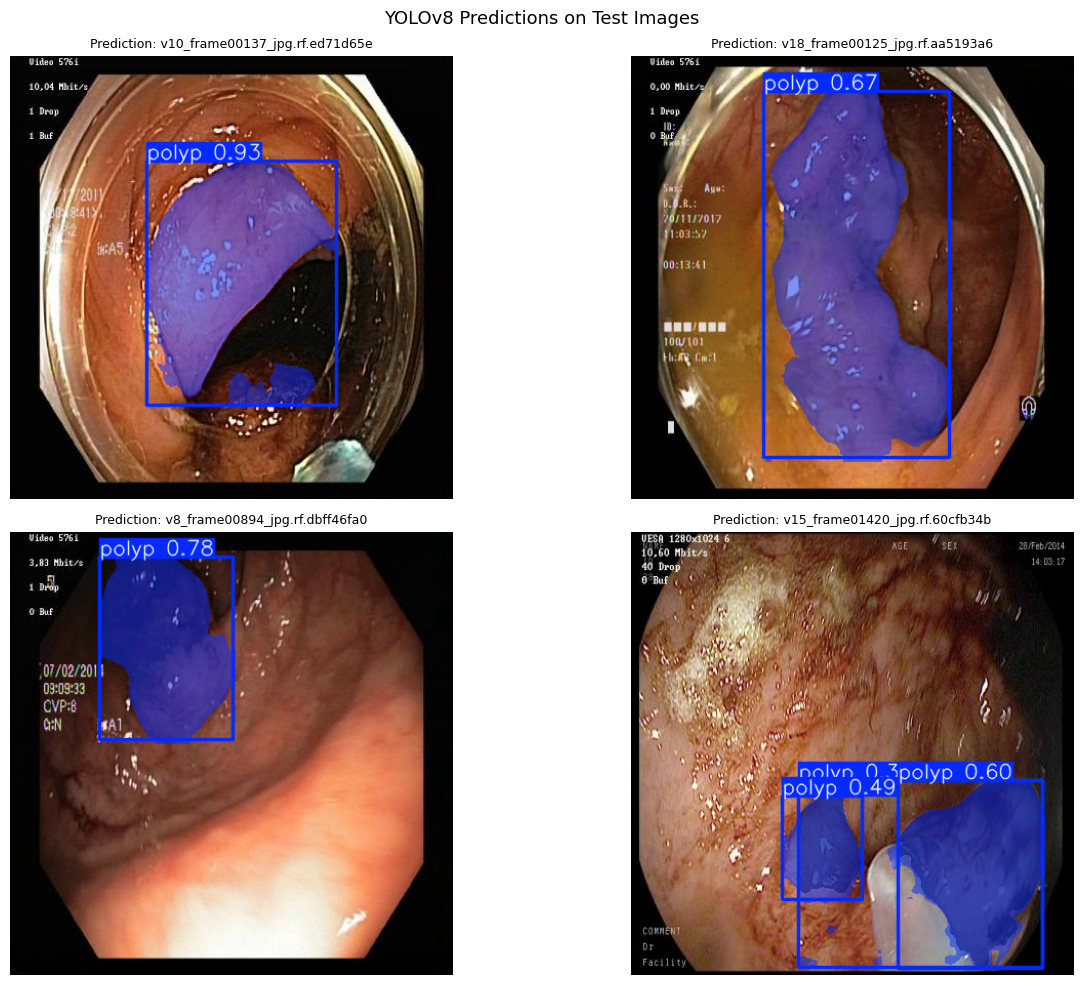

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

test_imgs = list((DATASET_DIR / "test" / "images").glob("*.jpg"))
samples   = random.sample(test_imgs, min(4, len(test_imgs)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    results    = model.predict(str(img_path), conf=0.3, verbose=False)
    annotated  = results[0].plot()
    annotated  = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated)
    axes[i].set_title(f"Prediction: {img_path.name[:30]}", fontsize=9)
    axes[i].axis("off")

plt.suptitle("YOLOv8 Predictions on Test Images", fontsize=13)
plt.tight_layout()
plt.show()

Columns available: ['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


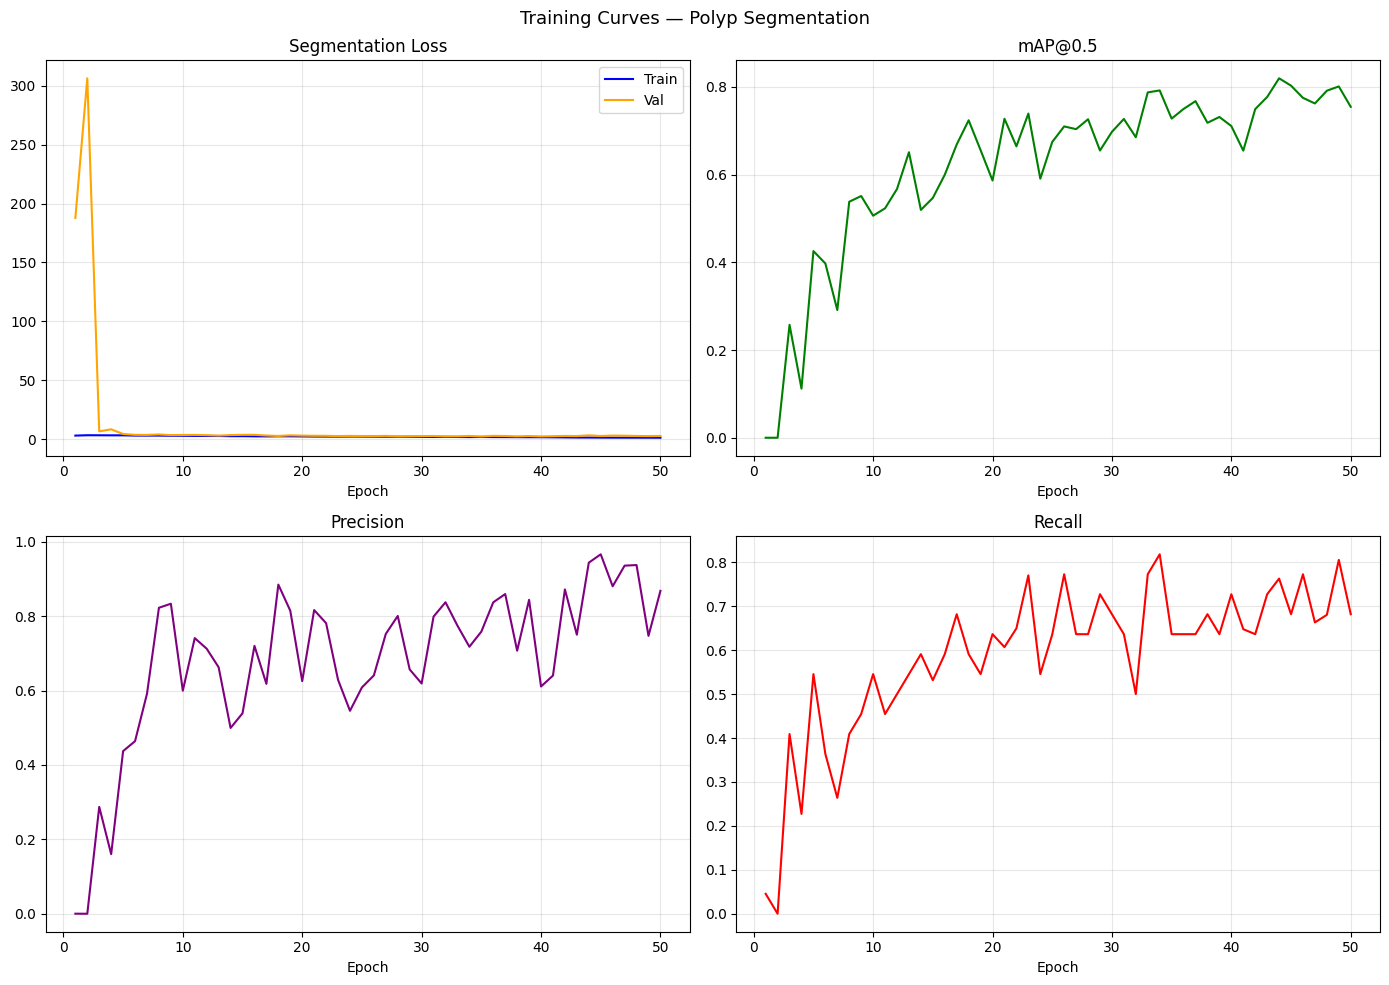

✅ Plot saved: /content/drive/MyDrive/ROI_Detection/models/polyp_seg_v1/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = f"{MODEL_SAVE_DIR}/polyp_seg_v1/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

print("Columns available:", list(df.columns))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(df["epoch"], df["train/seg_loss"], label="Train", color="blue")
axes[0,0].plot(df["epoch"], df["val/seg_loss"],   label="Val",   color="orange")
axes[0,0].set_title("Segmentation Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# mAP
map_col = [c for c in df.columns if "mAP50" in c and "(M)" in c]
if map_col:
    axes[0,1].plot(df["epoch"], df[map_col[0]], color="green")
axes[0,1].set_title("mAP@0.5")
axes[0,1].set_xlabel("Epoch")
axes[0,1].grid(True, alpha=0.3)

# Precision
prec_col = [c for c in df.columns if "precision" in c.lower() and "(M)" in c]
if prec_col:
    axes[1,0].plot(df["epoch"], df[prec_col[0]], color="purple")
axes[1,0].set_title("Precision")
axes[1,0].set_xlabel("Epoch")
axes[1,0].grid(True, alpha=0.3)

# Recall
rec_col = [c for c in df.columns if "recall" in c.lower() and "(M)" in c]
if rec_col:
    axes[1,1].plot(df["epoch"], df[rec_col[0]], color="red")
axes[1,1].set_title("Recall")
axes[1,1].set_xlabel("Epoch")
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Training Curves — Polyp Segmentation", fontsize=13)
plt.tight_layout()

plot_path = f"{MODEL_SAVE_DIR}/polyp_seg_v1/training_curves.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✅ Plot saved: {plot_path}")